In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

In [ ]:
offers = pd.read_csv('df_offers.csv')
placements = pd.read_csv('df_placements.csv')
stats = pd.read_csv('df_stats.csv')
orders = pd.read_csv('df_orders.csv')

# Очистка числовых
for df in [stats, orders]:
    for col in ['views', 'clicks', 'GMV', 'reward_author']:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col].str.replace(',', '.'), errors='coerce')

print("Загрузка готова. Размеры:")
print(f"Offers: {offers.shape}, Placements: {placements.shape}, Stats: {stats.shape}, Orders: {orders.shape}")

Загрузка готова. Размеры:
Offers: (28582, 15), Placements: (93479, 9), Stats: (87396, 4), Orders: (71825, 9)


In [ ]:
# Ключи в строки
for df in [placements, stats, orders, offers]:
    for col in ['hash_placement_id', 'hash_offer_id', 'hash_author_id', 'hash_seller_id', 'hash_model_id']:
        if col in df.columns:
            df[col] = df[col].astype(str)

# Merge
df = placements.merge(stats, on='hash_placement_id', how='left')
df = df.merge(offers, on='hash_offer_id', how='left')
df = df.merge(orders, on='hash_placement_id', how='left')

# Исправление placement_format (выбираем из placements, fill NaN)
df['placement_format'] = df['placement_format_x'].fillna(df['placement_format_y']).fillna('')
df = df.drop(['placement_format_x', 'placement_format_y'], axis=1)

# Удаление Unnamed
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Merge готов. Размер df:", df.shape)
print("\nУникальные placement_format в df:", df['placement_format'].unique())
print(df.head())

Merge готов. Размер df: (113373, 20)

Уникальные placement_format в df: ['post' 'clip']
                                   hash_placement_id  \
0  6B86B273FF34FCE19D6B804EFF5A3F5747ADA4EAA22F1D...   
1  D4735E3A265E16EEE03F59718B9B5D03019C07D8B6C51F...   
2  4E07408562BEDB8B60CE05C1DECFE3AD16B72230967DE0...   
3  4B227777D4DD1FC61C6F884F48641D02B4D121D3FD328C...   
4  EF2D127DE37B942BAAD06145E54B0C619A1F22327B2EBB...   

        placement_created_at  \
0  2025-07-14 14:00:00+03:00   
1  2025-07-14 14:00:00+03:00   
2  2025-07-14 14:00:00+03:00   
3  2025-07-14 14:00:00+03:00   
4  2025-07-14 14:00:00+03:00   

                                      hash_author_id  \
0  CE741A4B1DCCAA73955AB83ECDC59DB7CAAA65F955D543...   
1  27335C6F0F67CB71EB11377AA44C8C1DEE360050E9C98B...   
2  36684976BE1F529E6E2A32C9EDAB4CF8E364B2B916AE2C...   
3  CE741A4B1DCCAA73955AB83ECDC59DB7CAAA65F955D543...   
4  E1CBED0ECBEE7325A4820B48E02453E8A4E5FE0A2F47FC...   

                                       hash_o

GMV (Gross Merchandise Value) — Общая Стоимость Товаров
GMV — это общая стоимость всех заказов (продаж)

In [ ]:
gmv_cat = df[df['order_status_code'] == '5'].groupby('category')['GMV'].sum().sort_values(ascending=False)
print("Топ GMV по категориям:\n", gmv_cat.head(5))

Топ GMV по категориям:
 category
Дом и дача            31569132.0
Гардероб              23227320.0
Красота и здоровье    17413176.0
Бытовая техника       12174731.0
Спорт и отдых         10972989.0
Name: GMV, dtype: float64


"Гардероб", "Дом и дача", "Красота и здоровье" - лидеры

Views по форматам:
 placement_format
clip    1.157964e+10
post    2.227887e+09
Name: views, dtype: float64
---------------
GMV по форматам:
 placement_format
clip    80439613.0
post    38341859.0
Name: GMV, dtype: float64


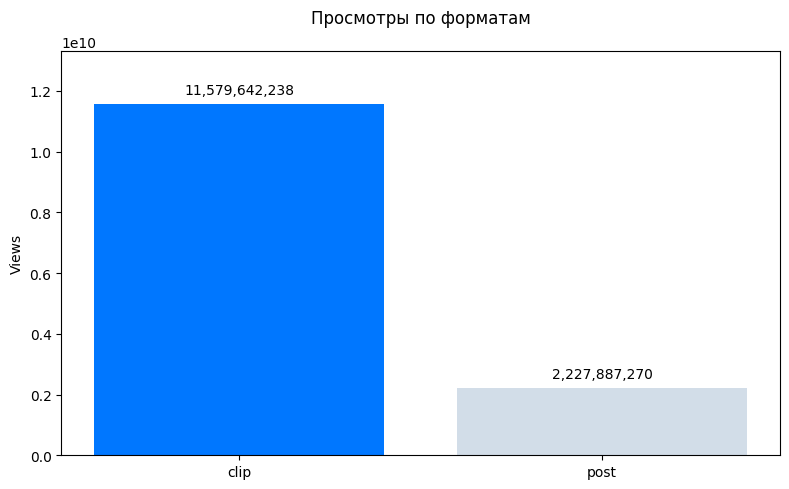

In [ ]:
# Views/GMV по форматам
views_format = df.groupby('placement_format')['views'].sum().sort_values(ascending=False)
gmv_format = df[df['order_status_code'] == '5'].groupby('placement_format')['GMV'].sum().sort_values(ascending=False)
print("Views по форматам:\n", views_format)
print("---------------")
print("GMV по форматам:\n", gmv_format)

# Визуализация Views по форматам
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(views_format.index, views_format.values, color=['#0077FF', '#d2dde8'])
ax.set_ylabel('Views')
ax.set_title('Просмотры по форматам', pad=20)

# Добавление значений на столбцы
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (views_format.max() * 0.02), f'{yval:,.0f}', ha='center', va='bottom')
ax.set_ylim(0, views_format.max() * 1.15)

plt.tight_layout()
plt.show()

Просмотры по форматам: clip: 11,579,640,000 post: 2,227,887,000

GMV по форматам: clip: 112,331,762 post: 58,969,613

In [ ]:
# Фильтры для клипов и постов
clips_df = df[df['placement_format'].str.contains('clip', case=False, na=False)].copy()
posts_df = df[df['placement_format'].str.contains('post', case=False, na=False)].copy()

print("Количество клипов:", len(clips_df))
print("Количество постов:", len(posts_df))

# Группировка по категориям
clips_category = clips_df.groupby('category').size().sort_values(ascending=False)
posts_category = posts_df.groupby('category').size().sort_values(ascending=False)

Количество клипов: 91792
Количество постов: 21581


Таблица соотношения кол-ва по категориям (топ 10):

                     Клипы (кол-во)  Посты (кол-во)  Клипы (%)  Посты (%)
category                                                                 
Дом и дача                    23165            5249       26.9       26.0
Гардероб                      20179            4723       23.5       23.4
Красота и здоровье            11873            3280       13.8       16.3
Спорт и отдых                 10176            2311       11.8       11.5
Бытовая техника                6642             578        7.7        2.9
Электроника                    3813             454        4.4        2.3
Детские товары                 2984            1008        3.5        5.0
Транспорт                      2533             406        2.9        2.0
Продукты питания               2403             729        2.8        3.6
Хобби и развлечения            2275            1433        2.6        7.1


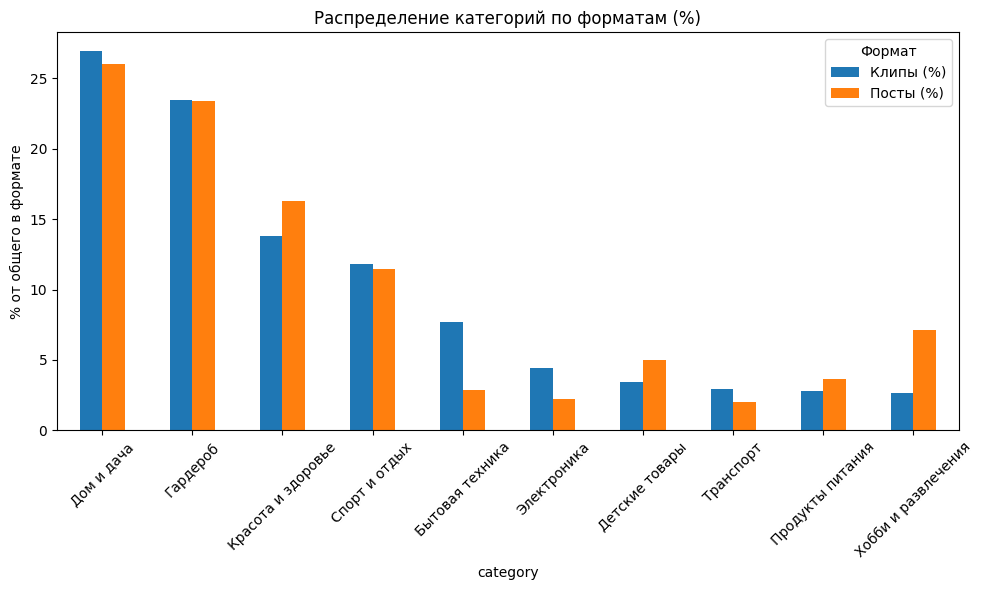

In [ ]:
# Общая таблица: левый столбец — клипы, правый — посты
all_categories = pd.concat([clips_category, posts_category], axis=1, sort=True).fillna(0)
all_categories.columns = ['Клипы (кол-во)', 'Посты (кол-во)']
all_categories = all_categories.sort_values('Клипы (кол-во)', ascending=False).head(10)  # Топ 10

# % относительно других категорий в формате
all_categories['Клипы (%)'] = (all_categories['Клипы (кол-во)'] / all_categories['Клипы (кол-во)'].sum()) * 100
all_categories['Посты (%)'] = (all_categories['Посты (кол-во)'] / all_categories['Посты (кол-во)'].sum()) * 100

print("Таблица соотношения кол-ва по категориям (топ 10):\n")
print(all_categories.round(1))

all_categories[['Клипы (%)', 'Посты (%)']].plot(kind='bar', figsize=(10,6))
plt.title('Распределение категорий по форматам (%)')
plt.ylabel('% от общего в формате')
plt.xticks(rotation=45)
plt.legend(title='Формат')
plt.tight_layout()
plt.savefig('category_format_comparison.png')
plt.show()

In [ ]:
# Группировка по категории (суммы для CTR/GMV, счёт для views per placement)
# Группировка views и clicks по всем данным
grouped_all = df.groupby('category').agg({
    'views': ['sum', 'count'],
    'clicks': 'sum'
}).round(2)
grouped_all.columns = ['sum_views', 'count_placements', 'sum_clicks']
grouped_all = grouped_all.reset_index()

# группировка GMV только по завершенным заказам
df_completed_orders_gmv = df[df['order_status_code'] == '5']
grouped_gmv_completed = df_completed_orders_gmv.groupby('category')['GMV'].sum().round(2).reset_index()
grouped_gmv_completed.columns = ['category', 'sum_gmv']

# Мердж
grouped = grouped_all.merge(grouped_gmv_completed, on='category', how='left')
grouped['sum_gmv'] = grouped['sum_gmv'].fillna(0) # Заполняем NaN нулями, если по категории не было завершенных заказов

print("Группировка готова. Топ 5 категорий по GMV (только завершенные заказы):\n", grouped.sort_values('sum_gmv', ascending=False).head(5))

Группировка готова. Топ 5 категорий по GMV (только завершенные заказы):
              category     sum_views  count_placements  sum_clicks     sum_gmv
4          Дом и дача  3.492411e+09             27303   2373524.0  31569132.0
2            Гардероб  1.814818e+09             23712   2403501.0  23227320.0
6  Красота и здоровье  3.280046e+09             14381   2420139.0  17413176.0
0     Бытовая техника  5.856652e+08              6883    355889.0  12174731.0
9       Спорт и отдых  8.134243e+08             11769    580405.0  10972989.0


Рассчитаны суммы просмотров, количество размещений, кликов, и GMV. Это база для всех метрик

Теперь расчитаем CTR - = (сумма кликов / сумма просмотров) для каждой категории. CTR показывает, насколько контент категории "цепляет" пользователей (высокий = востребовано, потенциал для блогеров).

In [ ]:
grouped['ctr'] = grouped['sum_clicks'] / grouped['sum_views']

top_ctr = grouped.nlargest(5, 'ctr')[['category', 'ctr']]
print("Топ-5 по CTR:\n", top_ctr)

Топ-5 по CTR:
                category       ctr
2              Гардероб  0.001324
13  Хобби и развлечения  0.001263
5   Канцелярские товары  0.001054
6    Красота и здоровье  0.000738
9         Спорт и отдых  0.000714


Расчёт Просмотров на Размещение (Топ-3)
Рассчитывает views per placement = (сумма просмотров / количество размещений) для каждой категории. Показывает охват на 1 пост (высокий = категория популярна у блогеров, легко монетизировать).

In [ ]:
grouped['views_per_placement'] = grouped['sum_views'] / grouped['count_placements']

top_views_per = grouped.nlargest(5, 'views_per_placement')[['category', 'views_per_placement']]
print("Топ-5 по Просмотрам на размещение:\n", top_views_per)

Топ-5 по Просмотрам на размещение:
                category  views_per_placement
11  Товары для животных        875378.830054
7      Продукты питания        341594.942787
6    Красота и здоровье        228081.902858
4            Дом и дача        127913.079515
14          Электроника        103462.385280


Расчёт GMV на Просмотр (Топ-3)
Рассчитывает GMV per view = (сумма выручки / сумма просмотров) для каждой категории. Показывает эффективность (сколько выручки на 1 просмотр — высокий = категория монетизируется через контент).

In [ ]:
grouped['gmv_per_view'] = grouped['sum_gmv'] / grouped['sum_views']

top_gmv_per_view = grouped.nlargest(5, 'gmv_per_view')[['category', 'gmv_per_view']]
print("Топ-5 по GMV на просмотр:\n", top_gmv_per_view)

Топ-5 по GMV на просмотр:
                   category  gmv_per_view
10     Товары для геймеров      0.034449
5      Канцелярские товары      0.033128
8   Ремонт и строительство      0.030757
13     Хобби и развлечения      0.023214
0          Бытовая техника      0.020788


Расчёт Корреляции Views-Clicks (Топ-3)
Рассчитывает корреляцию просмотров и кликов внутри каждой категории (функция corr_per_group). Ближе к 1 — лучше. Показывает вовлечённость (просмотры ведут к кликам — высокий = контент "работает").

Топ-5 по Корреляции views-clicks:
                category  corr_views_clicks
11  Товары для животных           0.984523
0       Бытовая техника           0.907511
3        Детские товары           0.904107
7      Продукты питания           0.774439
12            Транспорт           0.741570


/tmp/ipython-input-3536742648.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_df = df.groupby('category').apply(corr_per_group).reset_index(name='corr_views_clicks')



Корреляция views-clicks для клипов: 0.752
Корреляция views-clicks для постов: 0.353


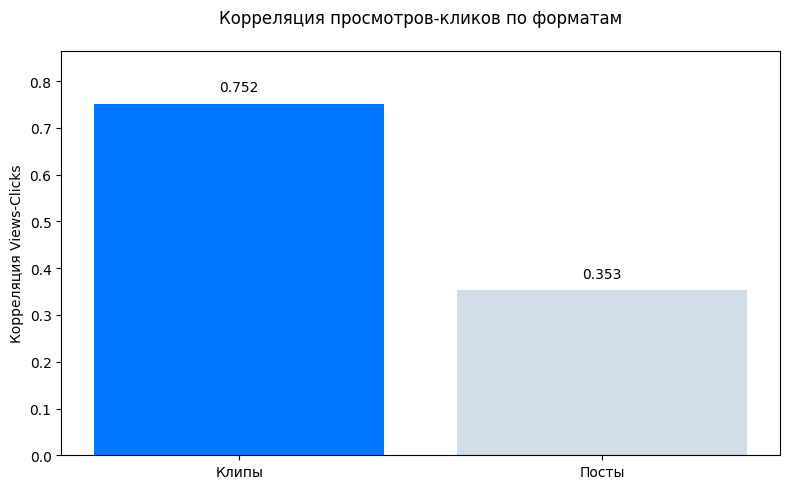

In [ ]:
def corr_per_group(group):
    if group['views'].notna().sum() > 1 and group['clicks'].notna().sum() > 1:
        return group['views'].corr(group['clicks'])
    return np.nan

corr_df = df.groupby('category').apply(corr_per_group).reset_index(name='corr_views_clicks')

top_corr = corr_df.nlargest(5, 'corr_views_clicks')[['category', 'corr_views_clicks']]
print("Топ-5 по Корреляции views-clicks:\n", top_corr)

# Расчет корреляции views-clicks для клипов и постов
clips_corr = df[df['placement_format'] == 'clip']['views'].corr(df[df['placement_format'] == 'clip']['clicks'])
posts_corr = df[df['placement_format'] == 'post']['views'].corr(df[df['placement_format'] == 'post']['clicks'])

print(f"\nКорреляция views-clicks для клипов: {clips_corr:.3f}")
print(f"Корреляция views-clicks для постов: {posts_corr:.3f}")

# Визуализация корреляции views-clicks для клипов и постов
correlation_data = pd.DataFrame({
    'Формат': ['Клипы', 'Посты'],
    'Корреляция': [clips_corr, posts_corr]
})

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(correlation_data['Формат'], correlation_data['Корреляция'], color=['#0077FF', '#d2dde8'])
ax.set_ylabel('Корреляция Views-Clicks')
ax.set_title('Корреляция просмотров-кликов по форматам', pad=20)

# Добавление значений на столбцы
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom')

ax.set_ylim(0, correlation_data['Корреляция'].max() * 1.15)
plt.tight_layout()
plt.show()

In [ ]:
# Views (from views_format)
clips_views_val = views_format.get('clip', 0)
posts_views_val = views_format.get('post', 0)

# Correlation views-click
clips_corr_val = clips_corr
posts_corr_val = posts_corr

# CTR for clips and posts
clips_ids = placements[placements['placement_format'] == 'clip']['hash_placement_id']
clips_stats = stats[stats['hash_placement_id'].isin(clips_ids)]
clips_views = clips_stats['views'].sum()
clips_clicks = clips_stats['clicks'].sum()
clips_ctr_val = (clips_clicks / clips_views) * 100 if clips_views > 0 else 0

posts_ids = placements[placements['placement_format'] == 'post']['hash_placement_id']
posts_stats = stats[stats['hash_placement_id'].isin(posts_ids)]
posts_views = posts_stats['views'].sum()
posts_clicks = posts_stats['clicks'].sum()
posts_ctr_val = (posts_clicks / posts_views) * 100 if posts_views > 0 else 0

# GMV per view
clips_gmv_val = gmv_format.get('clip', 0)
posts_gmv_val = gmv_format.get('post', 0)

clips_gmv_per_view = clips_gmv_val / clips_views_val if clips_views_val > 0 else 0
posts_gmv_per_view = posts_gmv_val / posts_views_val if posts_views_val > 0 else 0

comparison_data = {
    'Метрика': ['Кол-во просмотров', 'Корреляция просмотров-кликов', 'CTR (%)', 'GMV на просмотр'],
    'Клипы': [
        f'{clips_views_val / 1e9:.2f} млрд',
        f'{clips_corr_val:.2f}',
        f'{clips_ctr_val:.3f}',
        f'{clips_gmv_per_view:.4f}'
    ],
    'Посты': [
        f'{posts_views_val / 1e9:.2f} млрд',
        f'{posts_corr_val:.2f}',
        f'{posts_ctr_val:.3f}',
        f'{posts_gmv_per_view:.4f}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("Сравнительная таблица Clips vs Posts:")
print(comparison_df.set_index('Метрика'))
comparison_df

Сравнительная таблица Clips vs Posts:
                                   Клипы      Посты
Метрика                                            
Кол-во просмотров             11.58 млрд  2.23 млрд
Корреляция просмотров-кликов        0.75       0.35
CTR (%)                            0.015      0.073
GMV на просмотр                   0.0069     0.0172


,Метрика,Клипы,Посты
0,Кол-во просмотров,11.58 млрд,2.23 млрд
1,Корреляция просмотров-кликов,0.75,0.35
2,CTR (%),0.015,0.073
3,GMV на просмотр,0.0069,0.0172


Комбинированный Потенциал и Итоговая Таблица
Рассчитывает средний ранг всех метрик (CTR + views_per + gmv_per + corr + GMV) для баланса. Выводит топ-5 и всю таблицу. Комбинированный — общий "потенциал" категории (не только продажи, но и контент).

In [ ]:
grouped_with_corr = grouped.merge(corr_df, on='category', how='left')

# Заполнение NaN
grouped_with_corr['ctr'] = grouped_with_corr['ctr'].fillna(0)
grouped_with_corr['views_per_placement'] = grouped_with_corr['views_per_placement'].fillna(0)
grouped_with_corr['gmv_per_view'] = grouped_with_corr['gmv_per_view'].fillna(0)
grouped_with_corr['corr_views_clicks'] = grouped_with_corr['corr_views_clicks'].fillna(0)
grouped_with_corr['sum_gmv'] = grouped_with_corr['sum_gmv'].fillna(0)

# Нормализация (ранжирование) метрик
# Ранг от самого высокого к самому низкому. 'min_rank' - чтобы избежать пропусков при одинаковых значениях.
grouped_with_corr['rank_ctr'] = grouped_with_corr['ctr'].rank(ascending=True, method='min', pct=True)
grouped_with_corr['rank_views'] = grouped_with_corr['views_per_placement'].rank(ascending=True, method='min', pct=True)
grouped_with_corr['rank_gmv_per_view'] = grouped_with_corr['gmv_per_view'].rank(ascending=True, method='min', pct=True)
grouped_with_corr['rank_corr'] = grouped_with_corr['corr_views_clicks'].rank(ascending=True, method='min', pct=True)
grouped_with_corr['rank_sum_gmv'] = grouped_with_corr['sum_gmv'].rank(ascending=True, method='min', pct=True)

# Комбинированный потенциал (средний ранг)
grouped_with_corr['combined_potential'] = grouped_with_corr[[
    'rank_ctr',
    'rank_views',
    'rank_gmv_per_view',
    'rank_corr',
    'rank_sum_gmv'
]].mean(axis=1)

final_table = grouped_with_corr.nlargest(grouped_with_corr.shape[0], 'combined_potential')[[    'category', 'ctr', 'views_per_placement', 'gmv_per_view', 'corr_views_clicks', 'sum_gmv', 'combined_potential']]
print("\nИтоговая таблица (все категории):\n", final_table.round(3))

top_combined = grouped_with_corr.nlargest(6, 'combined_potential')[['category', 'combined_potential']]
print("\nТоп-6 по Комбинированному потенциалу:\n", top_combined.round(3))

final_table.to_csv('content_potential_table.csv', index=False)


Итоговая таблица (все категории):
                   category    ctr  views_per_placement  gmv_per_view  \
0          Бытовая техника  0.001            85088.657         0.021   
4               Дом и дача  0.001           127913.080         0.009   
6       Красота и здоровье  0.001           228081.903         0.005   
2                 Гардероб  0.001            76535.851         0.013   
3           Детские товары  0.000           102351.896         0.009   
14             Электроника  0.001           103462.385         0.010   
13     Хобби и развлечения  0.001            38779.244         0.023   
7         Продукты питания  0.000           341594.943         0.003   
11     Товары для животных  0.000           875378.830         0.002   
9            Спорт и отдых  0.001            69115.841         0.013   
5      Канцелярские товары  0.001            29008.264         0.033   
8   Ремонт и строительство  0.000            39538.582         0.031   
12               Транспорт  

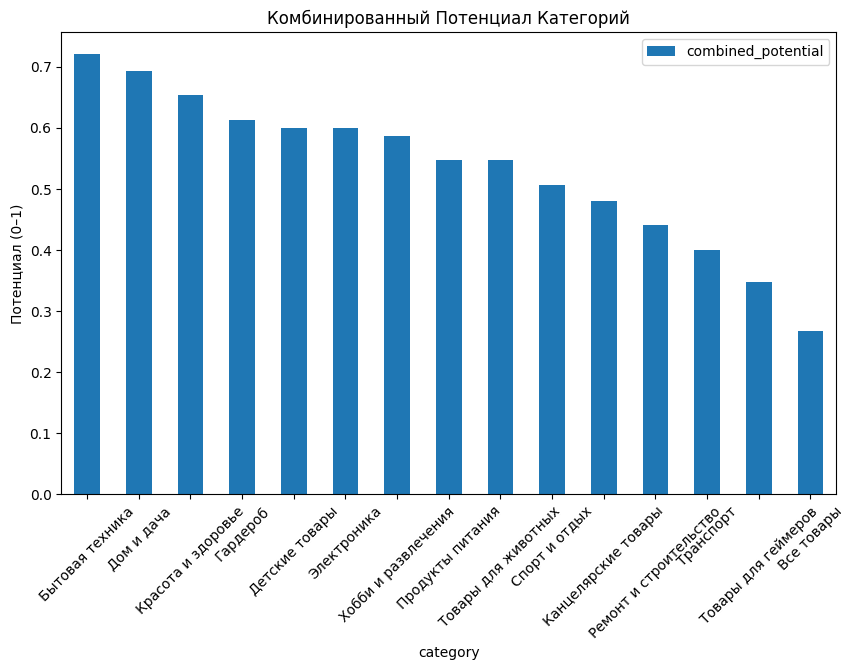

In [ ]:
final_table.plot(x='category', y='combined_potential', kind='bar', figsize=(10,6))
plt.title('Комбинированный Потенциал Категорий')
plt.ylabel('Потенциал (0–1)')
plt.xticks(rotation=45)
plt.savefig('combined_potential.png', dpi=300)
plt.show()

In [ ]:
final_table

,category,ctr,views_per_placement,gmv_per_view,corr_views_clicks,sum_gmv,combined_potential
0,Бытовая техника,0.000608,85088.657126,0.020788,0.907511,12174731.0,0.720000
4,Дом и дача,0.000680,127913.079515,0.009039,0.717598,31569132.0,0.693333
6,Красота и здоровье,0.000738,228081.902858,0.005309,0.634631,17413176.0,0.653333
2,Гардероб,0.001324,76535.851088,0.012799,0.318099,23227320.0,0.613333
3,Детские товары,0.000446,102351.895941,0.009089,0.904107,3414862.0,0.600000
14,Электроника,0.000586,103462.385280,0.009722,0.710478,4072740.0,0.600000
13,Хобби и развлечения,0.001263,38779.243517,0.023214,0.466097,3020203.0,0.586667
7,Продукты питания,0.000399,341594.942787,0.002953,0.774439,2873719.0,0.546667
11,Товары для животных,0.000315,875378.830054,0.001897,0.984523,2784975.0,0.546667
9,Спорт и отдых,0.000714,69115.841363,0.013490,0.308886,10972989.0,0.506667


ROI по Категориям (Топ-3)
Рассчитывает ROI = (reward_author / GMV) для блогеров по категории. Показывает, сколько монетизации от категории (высокий ROI — востребовано у блогеров для наполнения каталога).

In [ ]:
# ROI по категориям (эффективность монетизации для блогеров)
# группирjdrf views, clicks и reward_author по всем данным
grouped_all = df.groupby('category').agg({
    'views': ['sum', 'count'],
    'clicks': 'sum',
    'reward_author': 'sum'
}).round(2)
grouped_all.columns = ['sum_views', 'count_placements', 'sum_clicks', 'sum_reward_author']
grouped_all = grouped_all.reset_index()

# 2. Затем сгруппируем GMV только по завершенным заказам
df_completed_orders_gmv = df[df['order_status_code'] == '5']
grouped_gmv_completed = df_completed_orders_gmv.groupby('category')['GMV'].sum().round(2).reset_index()
grouped_gmv_completed.columns = ['category', 'sum_gmv']

# 3. Объединим результаты
grouped = grouped_all.merge(grouped_gmv_completed, on='category', how='left')
grouped['sum_gmv'] = grouped['sum_gmv'].fillna(0) # Заполняем NaN нулями, если по категории не было завершенных заказов
grouped['sum_reward_author'] = grouped['sum_reward_author'].fillna(0) # Заполняем NaN нулями, если не было reward_author

# 4. ROI = sum_reward_author / sum_gmv (комиссия / выручка)
grouped['roi'] = grouped.apply(lambda row: row['sum_reward_author'] / row['sum_gmv'] if row['sum_gmv'] > 0 else 0, axis=1)

# 5. Топ-3 по ROI
top_roi = grouped.nlargest(15, 'roi')[['category', 'roi']]
print("Топ-3 по ROI:\n", top_roi.round(3))

Топ-3 по ROI:
                   category    roi
2                 Гардероб  0.607
9            Спорт и отдых  0.461
1               Все товары  0.440
14             Электроника  0.413
13     Хобби и развлечения  0.393
4               Дом и дача  0.390
11     Товары для животных  0.375
5      Канцелярские товары  0.369
0          Бытовая техника  0.364
10     Товары для геймеров  0.346
8   Ремонт и строительство  0.337
6       Красота и здоровье  0.329
3           Детские товары  0.320
12               Транспорт  0.314
7         Продукты питания  0.302


Conversion Rate (по форматам)
Рассчитывает conversion = (orders / clicks) по форматам (клипы vs посты). Показывает, где клики превращаются в заказы (высокий — приоритет для наполнения каталога, селлерам).

In [ ]:
# Количество завершенных заказов
completed_orders_count = df[df['order_status_code'] == '5'].groupby('placement_format')['hash_order_id'].nunique()

# Сумма кликов по форматам (из всего датафрейма)
total_clicks_by_format = df.groupby('placement_format')['clicks'].sum()

# Объединяем и рассчитываем Conversion Rate
conv_format_df = pd.DataFrame({
    'num_completed_orders': completed_orders_count,
    'total_clicks': total_clicks_by_format
}).fillna(0) # Заполняем NaN нулями, если нет заказов или кликов

conv_format_df['conversion_rate'] = conv_format_df.apply(lambda row: row['num_completed_orders'] / row['total_clicks'] if row['total_clicks'] > 0 else 0, axis=1)
conv_format = conv_format_df['conversion_rate']

# Топ-3 по conversion
top_conv = conv_format.nlargest(3)
print("Топ-3 по Conversion Rate:\n", top_conv.round(3))

Топ-3 по Conversion Rate:
 placement_format
clip    0.003
post    0.002
Name: conversion_rate, dtype: float64


In [ ]:
# Корреляция reward-GMV по категориям (groupby + corr)
def corr_per_group(group):
    if len(group) > 1:
        return group['reward_author'].corr(group['GMV'])
    return np.nan

corr_df = df.groupby('category').apply(corr_per_group).reset_index(name='corr_reward_gmv')
corr_df = corr_df.dropna()

# Топ-3 по корреляции
top_corr_reward = corr_df.nlargest(3, 'corr_reward_gmv')[['category', 'corr_reward_gmv']]
print("Топ-3 по Корреляции reward-GMV:\n", top_corr_reward.round(3))

Топ-3 по Корреляции reward-GMV:
                category  corr_reward_gmv
0       Бытовая техника            0.998
10  Товары для геймеров            0.998
12            Транспорт            0.996


/tmp/ipython-input-1720829470.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_df = df.groupby('category').apply(corr_per_group).reset_index(name='corr_reward_gmv')


In [ ]:
total_views = stats['views'].sum()
total_clicks = stats['clicks'].sum()
overall_ctr = (total_clicks / total_views) * 100 if total_views > 0 else 0
print(f"Общий CTR: {overall_ctr:.2f}%")

Общий CTR: 0.03%


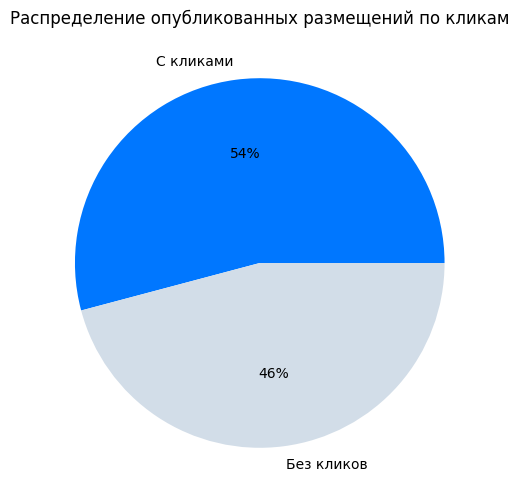

In [ ]:
published_placements = placements[placements['is_published'] == True]['hash_placement_id']
published_stats = stats[stats['hash_placement_id'].isin(published_placements)]
no_clicks = published_stats[published_stats['clicks'].fillna(0) == 0].shape[0]
total_published = published_stats.shape[0]
percent_no_clicks = (no_clicks / total_published) * 100 if total_published > 0 else 0

# Визуализация: пирог для распределения
labels = ['С кликами', 'Без кликов']
sizes = [100 - percent_no_clicks, percent_no_clicks]
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.0f%%', colors=['#0077FF', '#d2dde8'])
ax.set_title('Распределение опубликованных размещений по кликам')
plt.show()

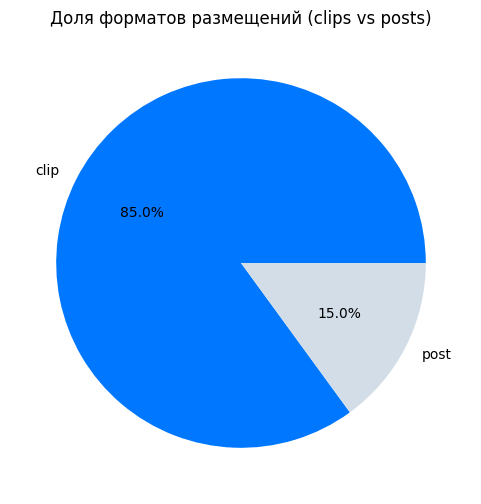

In [ ]:
total_placements = placements.shape[0]
clips_count = placements[placements['placement_format'] == 'clip'].shape[0]
clips_percent = (clips_count / total_placements) * 100 if total_placements > 0 else 0

format_counts = placements['placement_format'].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(format_counts, labels=format_counts.index, autopct='%1.1f%%', colors=['#0077FF', '#d2dde8'])
ax.set_title('Доля форматов размещений (clips vs posts)')
plt.show()

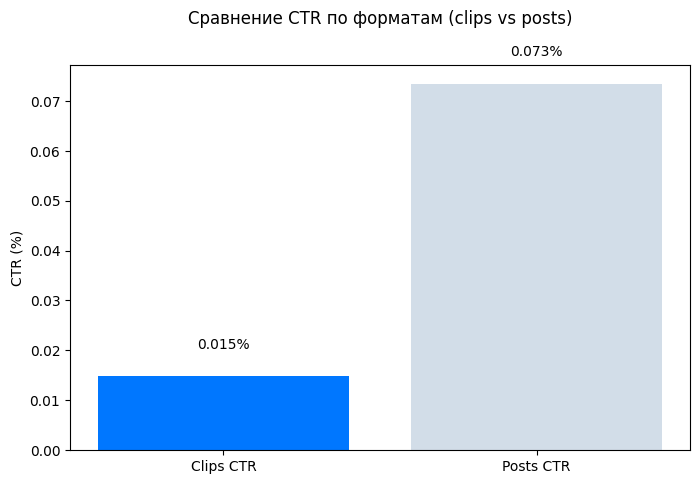

In [ ]:
clips_ids = placements[placements['placement_format'] == 'clip']['hash_placement_id']
clips_stats = stats[stats['hash_placement_id'].isin(clips_ids)]
clips_views = clips_stats['views'].sum()
clips_clicks = clips_stats['clicks'].sum()
clips_ctr = (clips_clicks / clips_views) * 100 if clips_views > 0 else 0

# Для сравнения: CTR posts
posts_ids = placements[placements['placement_format'] == 'post']['hash_placement_id']
posts_stats = stats[stats['hash_placement_id'].isin(posts_ids)]
posts_views = posts_stats['views'].sum()
posts_clicks = posts_stats['clicks'].sum()
posts_ctr = (posts_clicks / posts_views) * 100 if posts_views > 0 else 0

# Визуализация: бар-чарт сравнения CTR
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Clips CTR', 'Posts CTR'], [clips_ctr, posts_ctr], color=['#0077FF', '#d2dde8'])
ax.set_ylabel('CTR (%)')
ax.set_title('Сравнение CTR по форматам (clips vs posts)', pad=30)

# Добавление значений на столбцы
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}%', ha='center', va='bottom')

plt.show()

/tmp/ipython-input-2020236757.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category_ctr = df.groupby('category').apply(lambda g: (g['clicks'].sum() / g['views'].sum()) * 100 if g['views'].sum() > 0 else 0).reset_index(name='CTR')


Hobby CTR: 0.126%


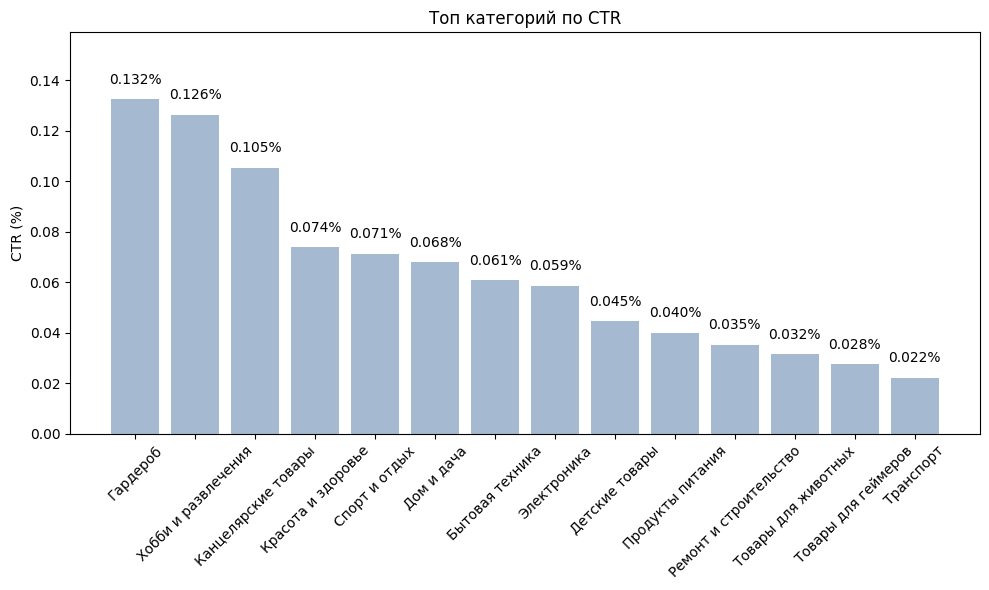

In [ ]:
category_ctr = df.groupby('category').apply(lambda g: (g['clicks'].sum() / g['views'].sum()) * 100 if g['views'].sum() > 0 else 0).reset_index(name='CTR')
hobby_ctr = category_ctr[category_ctr['category'] == 'Хобби и развлечения']['CTR'].values[0]
print(f"Hobby CTR: {hobby_ctr:.3f}%")

top_ctr = category_ctr.sort_values('CTR', ascending=False).head(14)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(top_ctr['category'], top_ctr['CTR'], color='#a5bad1')
ax.set_ylabel('CTR (%)')
ax.set_title('Топ категорий по CTR')
plt.xticks(rotation=45)

# Добавление значений на столбцы
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}%', ha='center', va='bottom')

ax.set_ylim(0, top_ctr['CTR'].max() * 1.2)

plt.tight_layout()
plt.show()

In [ ]:
category_gmv = df[df['order_status_code'] == '5'].groupby('category')['GMV'].sum() / 1e6  # в млн
home_gmv = category_gmv.get('Дом и дача', 0)

# таблица сравнения GMV по категориям для слайда
gmv_table = category_gmv.sort_values(ascending=False).reset_index(name='GMV (млн)')
gmv_table.head(14)  # Топ-10 для таблицы

,category,GMV (млн)
0,Дом и дача,31.569132
1,Гардероб,23.227320
2,Красота и здоровье,17.413176
3,Бытовая техника,12.174731
4,Спорт и отдых,10.972989
5,Электроника,4.072740
6,Детские товары,3.414862
7,Хобби и развлечения,3.020203
8,Продукты питания,2.873719
9,Товары для животных,2.784975


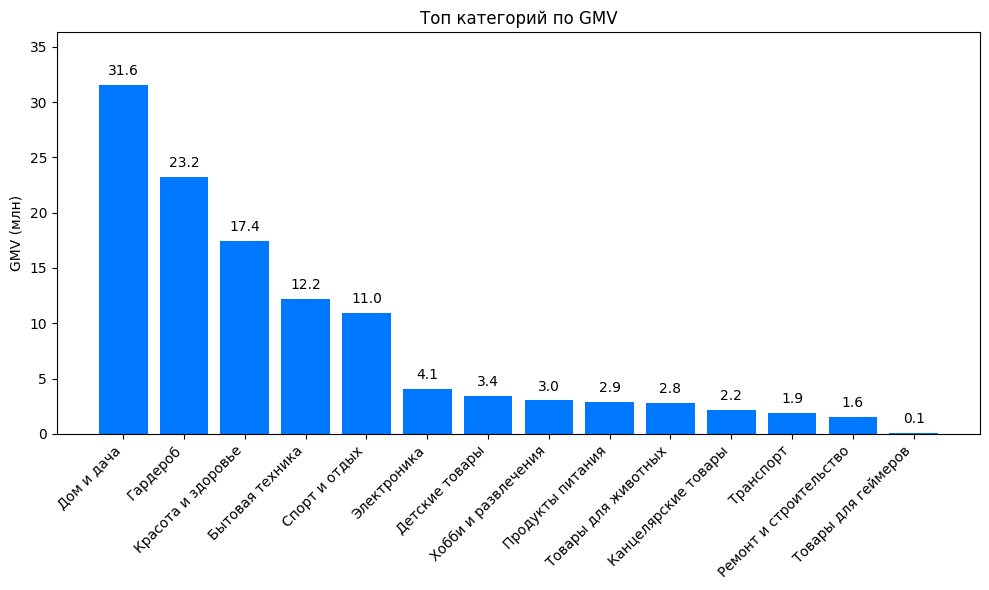

In [ ]:
category_gmv = df[df['order_status_code'] == '5'].groupby('category')['GMV'].sum() / 1e6  # в млн
category_gmv = category_gmv.drop('Все товары', errors='ignore')

top_gmv = category_gmv.sort_values(ascending=False).head(14)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(top_gmv.index, top_gmv.values, color='#0077FF')
ax.set_ylabel('GMV (млн)')
ax.set_title('Топ категорий по GMV')
plt.xticks(rotation=45, ha='right')

# Добавление значений на столбцы
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (top_gmv.max() * 0.02), f'{yval:.1f}', ha='center', va='bottom')

ax.set_ylim(0, top_gmv.max() * 1.15)

plt.tight_layout()
plt.show()

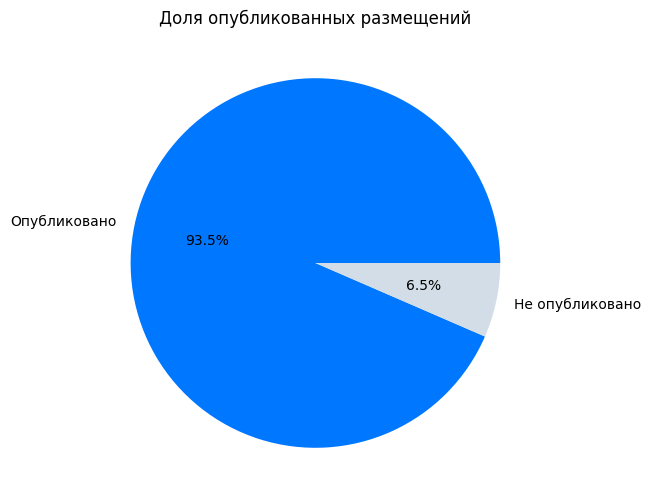

In [ ]:
not_published = placements[placements['is_published'] == False].shape[0]
total_placements = placements.shape[0]
percent_not_published = (not_published / total_placements) * 100 if total_placements > 0 else 0

labels = ['Опубликовано', 'Не опубликовано']
sizes = [100 - percent_not_published, percent_not_published]
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#0077FF', '#d2dde8'])
ax.set_title('Доля опубликованных размещений')
plt.show()

Общий CPO: 1528.80
CPO по форматам:
                   total_reward  num_orders          CPO
placement_format                                       
clip                23356700.0       14983  1558.880064
post                11524504.0        7833  1471.275884


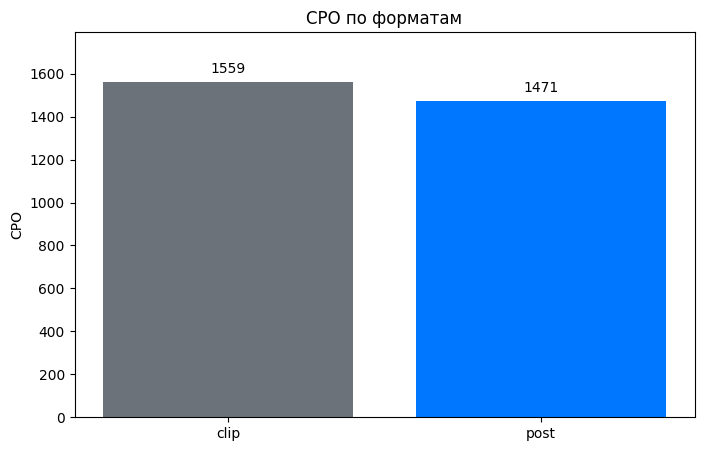

CPO по категориям:
                         total_reward  num_orders          CPO
category                                                     
Продукты питания            778345.0         922   844.191974
Красота и здоровье         4802105.0        5381   892.418695
Хобби и развлечения         864483.0         726  1190.747934
Дом и дача                10204256.0        8271  1233.739088
Транспорт                   487831.0         378  1290.558201
Товары для животных         919131.0         580  1584.708621
Канцелярские товары         615911.0         376  1638.061170
Детские товары              903251.0         480  1881.772917
Товары для геймеров          21953.0          10  2195.300000
Спорт и отдых              3135293.0        1371  2286.865791
Гардероб                   7096403.0        2824  2512.890581
Все товары                   36695.0          12  3057.916667
Электроника                1082132.0         336  3220.630952
Ремонт и строительство      400381.0         120  

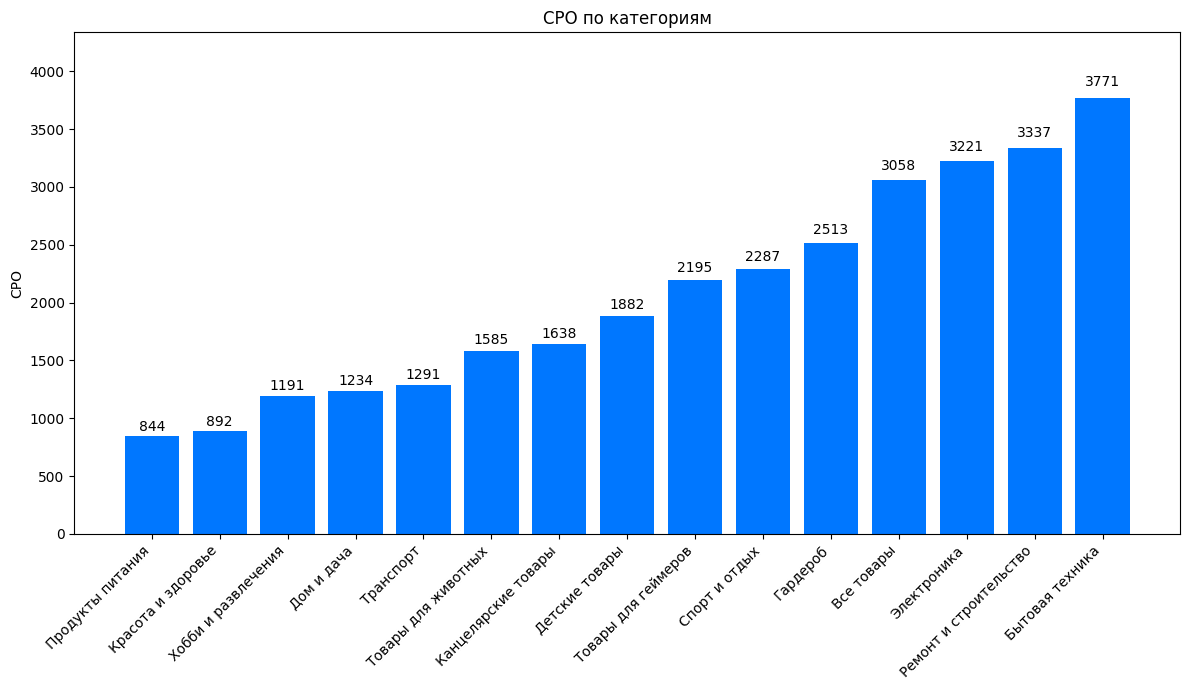

In [ ]:
completed_orders = df[df['order_status_code'] == '5'].dropna(subset=['reward_author'])

# Проверка на наличие выполненных заказов
if completed_orders.empty:
    print("Нет выполненных заказов с указанным статусом для расчета CPO.")
    # Устанавливаем CPO в 0 и не пытаемся строить графики
    overall_cpo = 0.0
else:
    # Общий CPO
    total_reward = completed_orders['reward_author'].sum()
    num_orders = completed_orders['hash_order_id'].nunique()
    overall_cpo = total_reward / num_orders if num_orders > 0 else 0
    print(f"Общий CPO: {overall_cpo:.2f}")

    # По форматам (если placement_format в df)
    if 'placement_format' in df.columns:
        cpo_by_format = completed_orders.groupby('placement_format').agg(
            total_reward=('reward_author', 'sum'),
            num_orders=('hash_order_id', 'nunique')
        )
        cpo_by_format['CPO'] = cpo_by_format.apply(lambda row: row['total_reward'] / row['num_orders'] if row['num_orders'] > 0 else 0, axis=1)
        cpo_by_format = cpo_by_format[cpo_by_format['CPO'].notna() & (cpo_by_format['CPO'] != 0)] # Фильтруем NaN и нули

        if not cpo_by_format.empty:
            print("CPO по форматам:\n", cpo_by_format)
            fig, ax = plt.subplots(figsize=(8, 5))
            bars = ax.bar(cpo_by_format.index, cpo_by_format['CPO'], color=['#6b727a', '#0077FF'])
            ax.set_ylabel('CPO')
            ax.set_title('CPO по форматам')

            for bar in bars:
                yval = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:.0f}', ha='center', va='bottom')
            ax.set_ylim(0, cpo_by_format['CPO'].max() * 1.15)
            plt.show()
        else:
            print("Нет данных для построения CPO по форматам.")

    # По категориям (если category в df)
    if 'category' in df.columns:
        cpo_by_category = completed_orders.groupby('category').agg(
            total_reward=('reward_author', 'sum'),
            num_orders=('hash_order_id', 'nunique')
        )
        cpo_by_category['CPO'] = cpo_by_category.apply(lambda row: row['total_reward'] / row['num_orders'] if row['num_orders'] > 0 else 0, axis=1)
        cpo_by_category = cpo_by_category[cpo_by_category['CPO'].notna() & (cpo_by_category['CPO'] != 0)] # Фильтруем NaN и нули

        if not cpo_by_category.empty:
            print("CPO по категориям:\n", cpo_by_category.sort_values('CPO'))

            fig, ax = plt.subplots(figsize=(12, 7))
            cpo_by_category_sorted = cpo_by_category.sort_values('CPO')
            bars = ax.bar(cpo_by_category_sorted.index, cpo_by_category_sorted['CPO'], color='#0077FF')
            ax.set_ylabel('CPO')
            ax.set_title('CPO по категориям')
            plt.xticks(rotation=45, ha='right')

            for bar in bars:
                yval = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.02), f'{yval:.0f}', ha='center', va='bottom')
            ax.set_ylim(0, cpo_by_category_sorted['CPO'].max() * 1.15)
            plt.tight_layout()
            plt.show()
        else:
            print("Нет данных для построения CPO по категориям.")

In [ ]:
!pip install numpy-financial

In [ ]:
import numpy_financial as npf
import pandas as pd
from IPython.display import display

# --- 1. РАСЧЕТ ТЕКУЩИХ БАЗОВЫХ МЕТРИК ИЗ ДАННЫХ ---

gmv_current = df[df['order_status_code'] == '5']['GMV'].sum()

df_clips = df[df['placement_format'] == 'clip'].copy()
clicks_clips = df_clips['clicks'].sum()
views_clips = df_clips['views'].sum()

ctr_clips_current = clicks_clips / (views_clips + 1e-9) if views_clips > 0 else 0
views_per_placement_current = df_clips['views'].mean()

# --- 2. ФАКТОРЫ РОСТА И ФИНАНСОВЫЕ ДОПУЩЕНИЯ (Основа - 5 Инициатив)

# Факторы роста GMV: (Снижены из-за меньшего числа инициатив)
factor_gmv_total_low = 0.20     # Консервативный рост
factor_gmv_total_high = 0.30    # Оптимистичный рост
# Факторы роста CTR:
factor_ctr_clips_low = 1.8      # Кратный рост
factor_ctr_clips_high = 2.3     # Кратный рост
# Фактор роста Views/Placement:
factor_views_growth = 0.15      # Рост

# ФИНАНСОВЫЕ ДОПУЩЕНИЯ
profit_margin = 0.20            # Маржинальность
capex = 10_000_000              # Инвестиции
discount_rate = 0.10            # Ставка дисконтирования
project_period = 3              # Период оценки, лет
growth_rate_post_yr1 = 0.05     # Рост прибыли после 1 года

# --- 3. РАСЧЕТ ПРОГНОЗА И ФИНАНСОВЫХ МЕТРИК ---

# 3.1 Операционные метрики
gmv_forecast_low = gmv_current * (1 + factor_gmv_total_low)
gmv_forecast_high = gmv_current * (1 + factor_gmv_total_high)
ctr_clips_forecast_low = ctr_clips_current * factor_ctr_clips_low
ctr_clips_forecast_high = ctr_clips_current * factor_ctr_clips_high
views_per_placement_forecast = views_per_placement_current * (1 + factor_views_growth)

# 3.2 Финансовые метрики
gmv_forecast_avg = (gmv_forecast_low + gmv_forecast_high) / 2
delta_gmv_year_1 = gmv_forecast_avg - gmv_current

# Чистый Денежный Поток
ncf_year_1 = delta_gmv_year_1 * profit_margin
ncf_year_2 = ncf_year_1 * (1 + growth_rate_post_yr1)
ncf_year_3 = ncf_year_2 * (1 + growth_rate_post_yr1)

cash_flows = [-capex, ncf_year_1, ncf_year_2, ncf_year_3]

npv = npf.npv(discount_rate, cash_flows)
irr = npf.irr(cash_flows)

# ROI
total_profit = ncf_year_1 + ncf_year_2 + ncf_year_3
roi_calc = (total_profit - capex) / capex

# --- 4. ФОРМИРОВАНИЕ ПЕРЕМЕННЫХ ДЛЯ ВЫВОДА В ТАБЛИЦУ ---
gmv_current_m = gmv_current / 1_000_000
gmv_low_m = gmv_forecast_low / 1_000_000
gmv_high_m = gmv_forecast_high / 1_000_000
ctr_current_p = ctr_clips_current * 100
ctr_low_p = ctr_clips_forecast_low * 100
ctr_high_p = ctr_clips_forecast_high * 100
views_current_k = views_per_placement_current / 1000
views_forecast_k = views_per_placement_forecast / 1000
npv_m = npv / 1_000_000
irr_p = irr * 100
roi_p = roi_calc * 100
capex_m = capex / 1_000_000

print("\n--- РЕЗУЛЬТАТЫ ФИНАЛЬНЫХ РАСЧЕТОВ ---")
print(f"Текущий gmv: {gmv_current_m:.1f} млн руб.")
print(f"Прогноз gmv: {gmv_low_m:.1f} - {gmv_high_m:.1f} млн руб.")
print(f"npv (Чистая Приведенная Стоимость): {npv_m:.1f} млн руб.")
print(f"roi (Рентабельность Инвестиций): {roi_p:.1f}%")
print(f"irr (Внутренняя Норма Доходности): {irr_p:.1f}%")

# 1. Таблица Операционного Прогноза
data_oper = {
    'Метрика': ['GMV (млн руб.)', 'CTR (Clips) (%)', 'Views/Placement (тыс.)', 'Вовлеченность (%)'],
    'Текущий Базис': [
        f"{gmv_current_m:.1f}",
        f"{ctr_current_p:.3f}",
        f"{views_current_k:.1f}K",
        "—"
    ],
    'Целевое Значение': [
        f"{gmv_low_m:.1f} - {gmv_high_m:.1f}",
        f"{ctr_low_p:.3f} - {ctr_high_p:.3f}",
        f"{views_forecast_k:.1f}K",
        "+15 - 20"
    ],
    'Ожидаемый Рост': [
        '+20% - +30%',
        'x1.8 - x2.3',
        '+15%',
        'Прямой эффект И5'
    ]
}

df_oper = pd.DataFrame(data_oper)

# 2. Таблица Финансовой Эффективности
data_fin = {
    'Метрика': ['Общие Инвестиции', 'Чистая Приведенная Стоимость', 'Рентабельность Инвестиций', 'Внутренняя Норма Доходности'],
    'Обозначение': ['CAPEX', 'NPV', 'ROI', 'IRR'],
    'Результат': [
        f"{capex_m:.1f} млн руб.",
        f"{npv_m:.1f} млн руб.",
        f"{roi_p:.1f}%",
        f"{irr_p:.1f}%"
    ],
    'Комментарий': [
        'Стоимость разработки GenAI и интеграции.',
        'Проект создает значительную стоимость.',
        'Каждая вложенная копейка приносит более чем двукратную отдачу.',
        'Ставка окупаемости значительно превышает стоимость капитала (10%).'
    ]
}

df_fin = pd.DataFrame(data_fin)

print("\n" + "="*50)
print("1. ОПЕРАЦИОННЫЙ ПРОГНОЗ (Слайд №8)")
print("="*50)
display(df_oper)

print("\n" + "="*50)
print("2. ФИНАНСОВАЯ ЭФФЕКТИВНОСТЬ (Слайд №8)")
print("="*50)
display(df_fin)


--- РЕЗУЛЬТАТЫ ФИНАЛЬНЫХ РАСЧЕТОВ ---
Текущий gmv: 118.8 млн руб.
Прогноз gmv: 142.5 - 154.4 млн руб.
npv (Чистая Приведенная Стоимость): 5.5 млн руб.
roi (Рентабельность Инвестиций): 87.2%
irr (Внутренняя Норма Доходности): 38.5%

1. ОПЕРАЦИОННЫЙ ПРОГНОЗ (Слайд №8)


,Метрика,Текущий Базис,Целевое Значение,Ожидаемый Рост
0,GMV (млн руб.),118.8,142.5 - 154.4,+20% - +30%
1,CTR (Clips) (%),0.042,0.076 - 0.097,x1.8 - x2.3
2,Views/Placement (тыс.),132.6K,152.5K,+15%
3,Вовлеченность (%),—,+15 - 20,Прямой эффект И5



2. ФИНАНСОВАЯ ЭФФЕКТИВНОСТЬ (Слайд №8)


,Метрика,Обозначение,Результат,Комментарий
0,Общие Инвестиции,CAPEX,10.0 млн руб.,Стоимость разработки GenAI и интеграции.
1,Чистая Приведенная Стоимость,NPV,5.5 млн руб.,Проект создает значительную стоимость.
2,Рентабельность Инвестиций,ROI,87.2%,Каждая вложенная копейка приносит более чем дв...
3,Внутренняя Норма Доходности,IRR,38.5%,Ставка окупаемости значительно превышает стоим...
